# Codveda Data Analytics Internship - Level 2 (Intermediate)

**Intern:** Abubakar Rabiu Salihawa  
**Internship:** Data Analysis Intern, Codveda Technologies  
**Intern ID:** CV/AI/82271  

Selected tasks: **Task 1 - Regression Analysis** and **Task 2 - Time Series Analysis**.

This notebook records the steps I followed, the results obtained, and what the results mean. The code is included so that the analysis can be checked and repeated.

## Task 1: Regression Analysis

The house-prediction file is the Boston Housing dataset stored as whitespace-separated values without a header row. The target variable is `MEDV`, the median value of owner-occupied homes in thousands of dollars. A simple linear regression is built using `RM` (average number of rooms per dwelling) because the task asks to predict one variable from another.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Keep charts simple and consistent with an ordinary analyst report.
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': False,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10
})
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose

ROOT = Path.cwd().parent
DATA = ROOT / 'data'
OUT = ROOT / 'outputs' / 'level2'
OUT.mkdir(parents=True, exist_ok=True)

columns = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']
housing = pd.read_csv(DATA / 'house_prediction.txt', sep=r'\s+', header=None, names=columns)
print('Dataset shape:', housing.shape)
display(housing.head())
display(housing[['RM','MEDV']].describe().round(3))

Dataset shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


,RM,MEDV
count,506.000,506.000
mean,6.285,22.533
std,0.703,9.197
min,3.561,5.000
25%,5.885,17.025
50%,6.208,21.200
75%,6.624,25.000
max,8.780,50.000


In [2]:
X = housing[['RM']]
y = housing['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
coefficient = model.coef_[0]
intercept = model.intercept_

metrics = pd.DataFrame({
    'Metric': ['Intercept', 'Coefficient for RM', 'R-squared', 'Mean Squared Error', 'Root Mean Squared Error'],
    'Value': [intercept, coefficient, r2, mse, rmse]
})
metrics.to_csv(OUT / 'regression_metrics.csv', index=False)
display(metrics.round(4))

print(f'Estimated equation: MEDV = {intercept:.3f} + ({coefficient:.3f} × RM)')
print(f'Interpretation: one additional room is associated with an estimated ${coefficient*1000:,.0f} increase in median house value, on average.')

,Metric,Value
0,Intercept,-36.2463
1,Coefficient for RM,9.3483
2,R-squared,0.3708
3,Mean Squared Error,46.1448
4,Root Mean Squared Error,6.7930


Estimated equation: MEDV = -36.246 + (9.348 × RM)
Interpretation: one additional room is associated with an estimated $9,348 increase in median house value, on average.


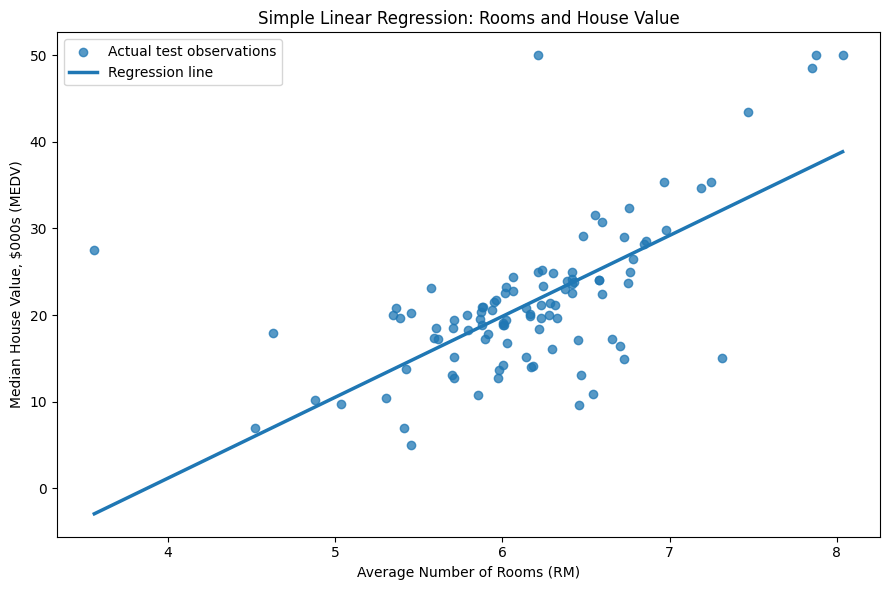

In [3]:
plt.figure(figsize=(9, 6))
plt.scatter(X_test['RM'], y_test, alpha=0.75, label='Actual test observations')
order = np.argsort(X_test['RM'].values)
plt.plot(X_test['RM'].values[order], y_pred[order], linewidth=2.5, label='Regression line')
plt.title('Simple Linear Regression: Rooms and House Value')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median House Value, $000s (MEDV)')
plt.legend()
plt.tight_layout()
plt.savefig(OUT / 'regression_rooms_vs_value.png', dpi=200, bbox_inches='tight')
plt.show()

### Regression interpretation

The coefficient is positive, confirming that houses in areas with more rooms tend to have higher median values. However, the R-squared value shows that room count alone does not explain all variation in house prices. Factors such as neighbourhood characteristics, accessibility, pollution, tax rate, and lower-status population percentage also matter. Therefore, this simple model is useful for demonstrating the relationship, but it should not be treated as a complete real-world valuation model.

## Task 2: Time Series Analysis

The stock dataset is filtered to Apple (`AAPL`) so that one continuous daily closing-price series can be analysed clearly. The work includes plotting the original series, calculating moving averages, and decomposing it into trend, seasonal, and residual components.

In [4]:
stock = pd.read_csv(DATA / 'stock_prices.csv', parse_dates=['date'])
aapl = (stock.loc[stock['symbol'].eq('AAPL'), ['date','close']]
        .dropna()
        .drop_duplicates('date')
        .sort_values('date')
        .set_index('date'))

# Reindex to business days and interpolate occasional market-calendar gaps for decomposition.
business_index = pd.date_range(aapl.index.min(), aapl.index.max(), freq='B')
aapl_b = aapl.reindex(business_index)
aapl_b.index.name = 'date'
aapl_b['close'] = aapl_b['close'].interpolate(method='time').ffill().bfill()
aapl_b['MA_20'] = aapl_b['close'].rolling(20).mean()
aapl_b['MA_60'] = aapl_b['close'].rolling(60).mean()

print('Date range:', aapl_b.index.min().date(), 'to', aapl_b.index.max().date())
print('Business-day observations:', len(aapl_b))
display(aapl_b.head())

Date range: 2014-01-02 to 2017-12-29
Business-day observations: 1042


,close,MA_20,MA_60
date,,,
2014-01-02,79.0185,NaN,NaN
2014-01-03,77.2828,NaN,NaN
2014-01-06,77.7042,NaN,NaN
2014-01-07,77.1481,NaN,NaN
2014-01-08,77.6371,NaN,NaN


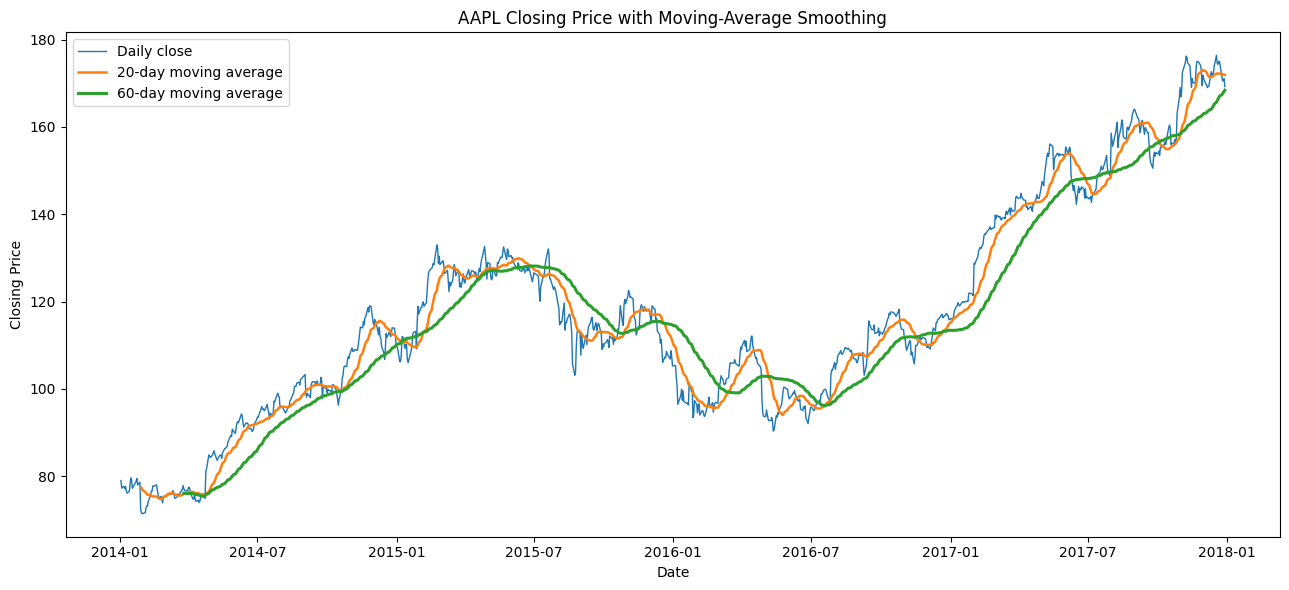

In [5]:
plt.figure(figsize=(13, 6))
plt.plot(aapl_b.index, aapl_b['close'], linewidth=1, label='Daily close')
plt.plot(aapl_b.index, aapl_b['MA_20'], linewidth=1.8, label='20-day moving average')
plt.plot(aapl_b.index, aapl_b['MA_60'], linewidth=2.2, label='60-day moving average')
plt.title('AAPL Closing Price with Moving-Average Smoothing')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.tight_layout()
plt.savefig(OUT / 'aapl_moving_averages.png', dpi=200, bbox_inches='tight')
plt.show()

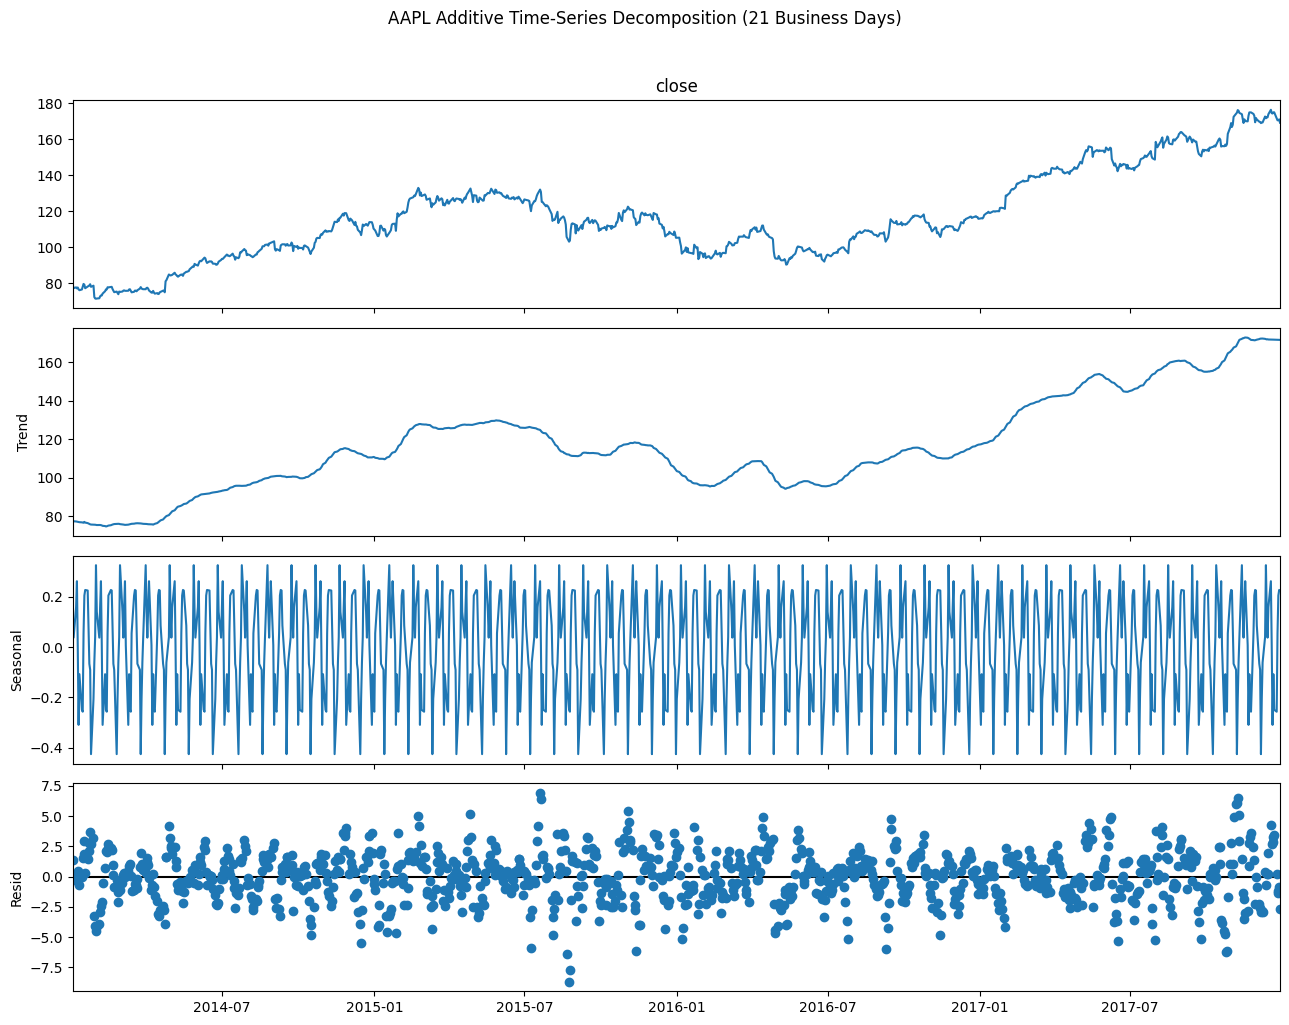

,close,trend,seasonal,residual,MA_20,MA_60
date,,,,,,
2014-03-26,77.1114,76.258295,-0.206660,1.059765,76.002435,76.119638
2014-03-27,76.7799,76.168976,-0.061080,0.672004,76.072360,76.082328
2014-03-28,76.6942,76.093871,0.040120,0.560209,76.148215,76.072518
2014-03-31,76.6771,76.073395,0.326401,0.277304,76.212360,76.055400
2014-04-01,77.3785,76.013667,0.140473,1.224360,76.286715,76.059240


In [6]:
# A 21-business-day period is used as an approximate trading month.
decomposition = seasonal_decompose(aapl_b['close'], model='additive', period=21, extrapolate_trend='freq')

fig = decomposition.plot()
fig.set_size_inches(13, 10)
fig.suptitle('AAPL Additive Time-Series Decomposition (21 Business Days)', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'aapl_decomposition.png', dpi=200, bbox_inches='tight')
plt.show()

components = pd.DataFrame({
    'close': aapl_b['close'],
    'trend': decomposition.trend,
    'seasonal': decomposition.seasonal,
    'residual': decomposition.resid,
    'MA_20': aapl_b['MA_20'],
    'MA_60': aapl_b['MA_60']
})
components.to_csv(OUT / 'aapl_time_series_components.csv')
display(components.dropna().head())

### Time-series findings

1. The long-term trend changes substantially over the period, showing that the closing price is not stationary.
2. The 20-day moving average reacts more quickly to price changes, while the 60-day moving average produces a smoother view of the longer-term direction.
3. The seasonal component based on a 21-business-day period is small relative to the trend and irregular price movements.
4. The residual component contains short-term shocks and market movements not explained by the selected trend and monthly trading-cycle approximation.

The decomposition is descriptive, not a trading recommendation. Stock prices are influenced by many external events, and past patterns do not guarantee future performance.

## Level 2 conclusion

For Level 2, I completed a simple linear regression and a time-series analysis. The model results, moving averages, and decomposition components are saved in the Level 2 output folder.